In [1]:
import matplotlib
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import namedtuple, deque
import random
import math
import numpy as np
from itertools import count

from Model.cnnmodel_ex import DQN

import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F

from reward_func import get_reward
from Game_Sim import game

In [2]:
# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "cpu"
)

print(device)

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

cpu


In [3]:
"""
    this keeps track of preiovus moves for training
"""

Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [4]:
# BATCH_SIZE is the number of transitions sampled from the replay buffer
# GAMMA is the discount factor as mentioned in the previous section
# EPS_START is the starting value of epsilon
# EPS_END is the final value of epsilon
# EPS_DECAY controls the rate of exponential decay of epsilon, higher means a slower decay
# TAU is the update rate of the target network
# LR is the learning rate of the ``AdamW`` optimizer
BATCH_SIZE = 128 # maybe try higher later
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 10000
TAU = 0.05
LR = 1e-5
TARGET_Q = 5000 # others used 10k

In [5]:
# policy_net = DQN(11).to(device) # F(State, Action) -> Reward
# target_net = DQN(11).to(device) # Maximize Reward
policy_net = DQN(1).to(device) # F(State, Action) -> Reward
target_net = DQN(1).to(device) # Maximize Reward
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)

In [6]:
steps_done = 0

from select_action import select_action

In [7]:
episode_durations = []

def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    # Take 100 episode averages and plot them too
    if len(durations_t) >= 100:
        means = durations_t.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(99), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

In [8]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
    # detailed explanation). This converts batch-array of Transitions
    # to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    
    state_batch = torch.cat(batch.state, dim=0)
    action_batch = torch.cat(batch.action, dim=0).unsqueeze(1)
    reward_batch = torch.cat(batch.reward, dim=0)
    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the
    # columns of actions taken. These are the actions which would've been taken
    # for each batch state according to policy_net
    # outputs 32x4 tensor
    state_action_values = policy_net(state_batch).gather(0, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based
    # on the "older" target_net; selecting their best reward with max(1).values
    # This is merged based on the mask, such that we'll have either the expected
    # state value or 0 in case the state was final.
    next_state_values = torch.zeros((BATCH_SIZE), device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch
    # print(state_action_values, expected_state_action_values)

    # Compute MSE loss
    criterion = nn.MSELoss()
    loss = criterion(state_action_values, expected_state_action_values)

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 10) # normal clipping was 100
    optimizer.step()

    return loss.item()

In [ ]:
num_episodes = 500 # epochs

model_loss = []

for i_episode in tqdm(range(num_episodes)):
    # Initialize the environment and get its state
    g = game.Game(multidimensional=True)
    num_episodes_w_no_movement = 0

    state = g.board.copy()
    # state = torch.tensor(state.flatten(), dtype=torch.float32, device=device).unsqueeze(0) # nn
    # state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0) # cnn
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0) # 3d cnn
    for t in count():
        prev = g.board.copy()

        action, steps_done = select_action(prev, target_net, steps_done, EPS_START, EPS_END, EPS_DECAY)
        
        # print('move is', action,'type is', type(action), end = "\r")
        success, combined_values, combined_indexes = g.move(action)
        action = torch.tensor([action], dtype=torch.int64, device=device)
        observation = g.board.copy()
        
        terminated = g.check_win()
        truncated = g.check_loss()

        reward = get_reward(prev, action, observation, terminated, truncated, success, combined_values, combined_indexes)
        # print('reward is', reward, 'won: ', terminated, 'lost: ', truncated, end="\r")
        
        reward = torch.tensor([reward], dtype=torch.float32, device=device)
        done = terminated or truncated

        if truncated:
            next_state = None
        else:
            # next_state = torch.tensor(observation.flatten(), dtype=torch.float32, device=device).unsqueeze(0)
            # next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0) # cnn
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0) # 3d cnn

        # Store the transition in memory
        memory.push(state, action, next_state, reward)

        # Move to the next state
        state = next_state

        # Perform one step of the optimization (on the policy network)
        loss = optimize_model()
        model_loss.append(loss)

        # Soft update of the target network's weights
        if steps_done % TARGET_Q == 0:
            print('updating static network')
            policy_net_state_dict = policy_net.state_dict()
            target_net.load_state_dict(policy_net_state_dict)

        if done:
            print('done with one epoch, max: ', g.max())
            # episode_durations.append(t + 1)
            # plot_durations()
            break

  0%|          | 0/500 [00:00<?, ?it/s]

done with one epoch, max:  64.0


/opt/miniconda3/envs/2048/lib/python3.9/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([128])) that is different to the input size (torch.Size([128, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
  0%|          | 2/500 [03:09<13:04:58, 94.58s/it]

done with one epoch, max:  128.0


  1%|          | 3/500 [04:21<11:48:11, 85.50s/it]

...

done with one epoch, max:  128.0


 12%|█▏        | 60/500 [3:49:22<30:19:46, 248.15s/it]

done with one epoch, max:  64.0


 12%|█▏        | 61/500 [3:56:56<37:48:17, 310.02s/it]

done with one epoch, max:  256.0


Complete


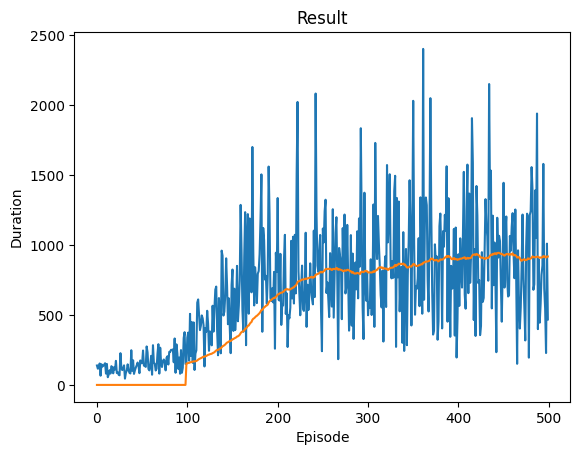

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
print('Complete')
plot_durations(show_result=True)
plt.ioff()
plt.show()

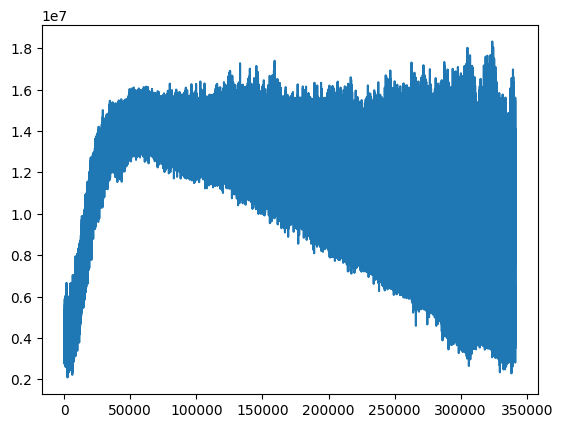

In [11]:
plt.plot(model_loss)
plt.show()

In [12]:
target_net_state_dict = target_net.state_dict()
policy_net_state_dict = policy_net.state_dict()

torch.save(target_net_state_dict, 'Model/saved_models/target_net.pt')
torch.save(policy_net_state_dict, 'Model/saved_models/policy_net.pt')